In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/decision_tree_for_DO/Delay.csv')
df.head()


,Traffic,TimeOfDay,VanType,Delayed
0,Low,Afternoon,Insulated Container Large,No
1,High,Evening,Insulated Container Standard,Yes
2,High,Evening,Refrigerated Container Standard,Yes
3,Low,Morning,Insulated Container Standard,No
4,High,Morning,Insulated Container Standard,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Traffic    30 non-null     object
 1   TimeOfDay  30 non-null     object
 2   VanType    30 non-null     object
 3   Delayed    30 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [ ]:
X = df[["Traffic", "TimeOfDay", "VanType"]]
y = df["Delayed"]

In [ ]:
y = y.map({"Yes": 1, "No": 0})
y.value_counts()


,count
Delayed,
1,17
0,13


In [ ]:
categorical_features = ["Traffic", "TimeOfDay", "VanType"]

categorical_transformer = OneHotEncoder(drop="first")
# drop="first" to avoid multicollinearity, also makes the feature more compact

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keep the Yes/No ratio even between train and test
)


In [ ]:
dt_clf = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", dt_clf)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Baseline accuracy: 0.5
Confusion matrix:
 [[1 2]
 [1 2]]
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



In [ ]:

param_grid = {
    "classifier__max_depth": [2, 3, 4, 5, None],
    "classifier__min_samples_split": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__criterion": ["gini", "entropy"]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,                 # Reduce the number of folds to 3 to avoid NaNs due to small data
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best CV accuracy: 0.5833333333333334


In [ ]:
import pandas as pd

# Convert cv_results_ to DataFrame for easy viewing
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Display columns related to scores
display(cv_results_df[['param_classifier__criterion', 'param_classifier__max_depth', 'param_classifier__min_samples_leaf', 'param_classifier__min_samples_split', 'mean_test_score', 'std_test_score']]
        .sort_values(by='mean_test_score', ascending=False).head())

# You can also check how many scores are NaN
print(f"The average number of test scores is NaN: {cv_results_df['mean_test_score'].isna().sum()} of the total number of {len(cv_results_df)} results.")

# Display the number of samples in the training and testing sets
print(f"Training set size: {len(X_train)}")
print(f"Class distribution in the training set (y_train):\n{y_train.value_counts()}")
print(f"Test set size: {len(X_test)}")
print(f"Class distribution in the testing set (y_test):\n{y_test.value_counts()}")

,param_classifier__criterion,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__min_samples_split,mean_test_score,std_test_score
5,gini,2,2,4,0.583333,0.058926
6,gini,2,2,6,0.583333,0.058926
4,gini,2,2,2,0.583333,0.058926
65,entropy,2,2,4,0.583333,0.058926
66,entropy,2,2,6,0.583333,0.058926


The average number of test scores is NaN: 0 of the total number of 120 results.
Training set size: 24
Class distribution in the training set (y_train):
Delayed
1    14
0    10
Name: count, dtype: int64
Test set size: 6
Class distribution in the testing set (y_test):
Delayed
0    3
1    3
Name: count, dtype: int64


In [ ]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Test accuracy (best model):", accuracy_score(y_test, y_pred_best))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification report:\n", classification_report(y_test, y_pred_best))


Test accuracy (best model): 0.5
Confusion matrix:
 [[0 3]
 [0 3]]
Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


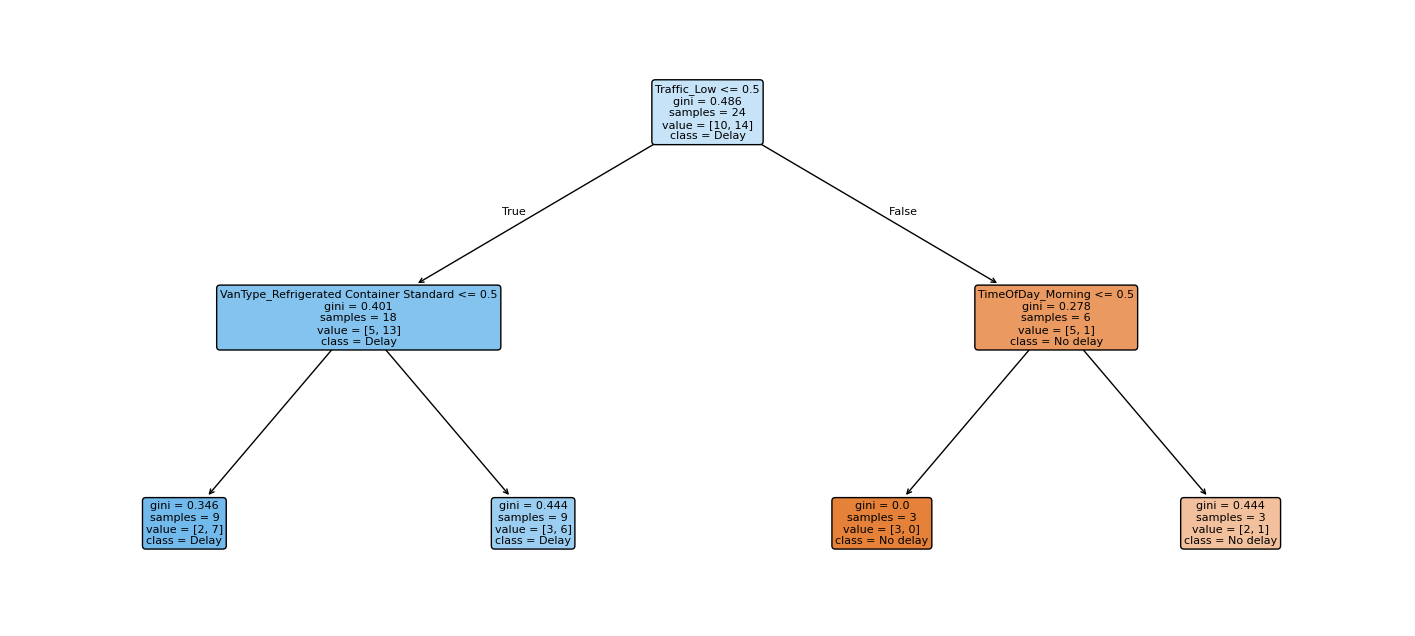

In [ ]:
# best_model là Pipeline
best_tree = best_model.named_steps["classifier"]
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]

# Lấy tên feature sau OneHotEncoding
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

plt.figure(figsize=(18, 8))
plot_tree(
    best_tree,
    feature_names=encoded_feature_names,
    class_names=["No delay", "Delay"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


In [ ]:
feature_importances = best_tree.feature_importances_
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

feature_importance_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': feature_importances
})

print("Feature Importances for encoded features:")
display(feature_importance_df.sort_values(by='Importance', ascending=False))


Feature Importances for encoded features:


,Feature,Importance
0,Traffic_Low,0.862069
3,TimeOfDay_Morning,0.103448
6,VanType_Refrigerated Container Standard,0.034483
2,TimeOfDay_Evening,0.000000
1,Traffic_Medium,0.000000
4,VanType_Insulated Container Standard,0.000000
5,VanType_Refrigerated Container Large,0.000000


In [ ]:
aggregated_importance = {
    'Traffic': 0,
    'TimeOfDay': 0,
    'VanType': 0
}

for index, row in feature_importance_df.iterrows():
    feature_name = row['Feature']
    importance = row['Importance']

    # Determine the original feature category
    if feature_name.startswith('Traffic_'):
        aggregated_importance['Traffic'] += importance
    elif feature_name.startswith('TimeOfDay_'):
        aggregated_importance['TimeOfDay'] += importance
    elif feature_name.startswith('VanType_'):
        aggregated_importance['VanType'] += importance

aggregated_importance_df = pd.DataFrame(list(aggregated_importance.items()), columns=['Original Feature', 'Aggregated Importance'])
aggregated_importance_df = aggregated_importance_df.sort_values(by='Aggregated Importance', ascending=False)

print("Aggregated Feature Importances for Original Features:")
display(aggregated_importance_df)


Aggregated Feature Importances for Original Features:


,Original Feature,Aggregated Importance
0,Traffic,0.862069
1,TimeOfDay,0.103448
2,VanType,0.034483


/tmp/ipython-input-1619492312.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Original Feature', y='Aggregated Importance', data=aggregated_importance_df, palette='viridis')


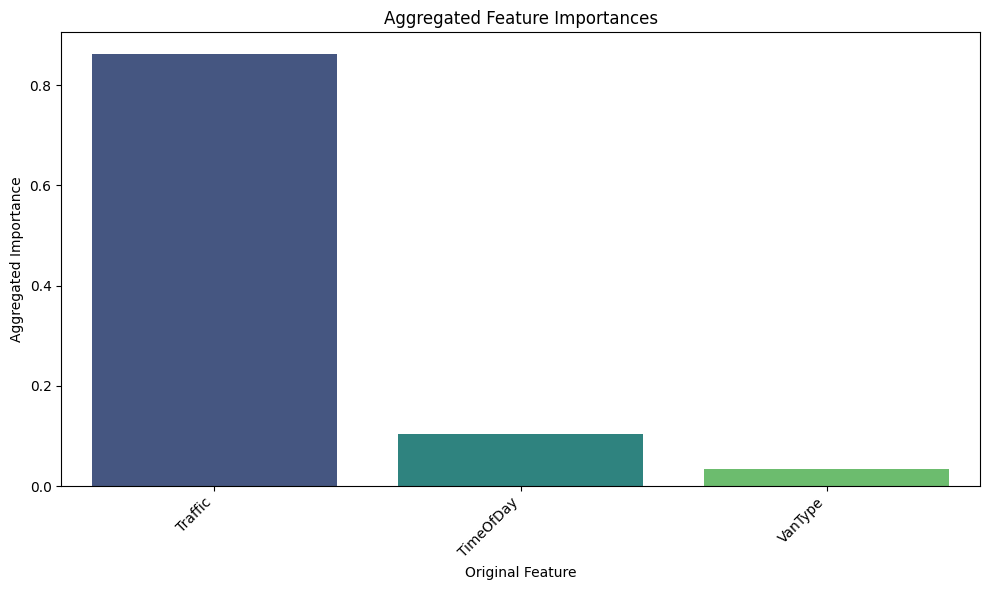

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Original Feature', y='Aggregated Importance', data=aggregated_importance_df, palette='viridis')
plt.title('Aggregated Feature Importances')
plt.xlabel('Original Feature')
plt.ylabel('Aggregated Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


2. models Compare

In [ ]:
from sklearn.model_selection import cross_val_score

# Re-split X_raw and y (from the hardcoded dataset in cell Uo5g8PFlyBzH)
# to get raw X_train and y_train that the 'model' pipeline expects.
# Note: This X_raw and y refer to the data from the hardcoded dataset.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate CV score for the baseline model using the raw features
baseline_cv_scores = cross_val_score(model, X_train_raw, y_train_raw, cv=3, scoring='accuracy', n_jobs=-1)
baseline_mean_cv = baseline_cv_scores.mean()
baseline_std_cv = baseline_cv_scores.std()

print(f"Baseline Model - Mean CV Accuracy: {baseline_mean_cv:.4f} (Std: {baseline_std_cv:.4f})")

# Get CV information from GridSearchCV's best model
best_tuned_mean_cv = grid_search.best_score_
# grid_search.best_index_ cho biết index của best_params trong cv_results_
best_tuned_std_cv = cv_results_df.loc[grid_search.best_index_, 'std_test_score']

print(f"Tuned Model (Best GridSearch) - Mean CV Accuracy: {best_tuned_mean_cv:.4f} (Std: {best_tuned_std_cv:.4f})")

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'Mean CV Accuracy': [baseline_mean_cv, best_tuned_mean_cv],
    'Std CV Accuracy': [baseline_std_cv, best_tuned_std_cv]
})

display(comparison_df)

Baseline Model - Mean CV Accuracy: 0.4167 (Std: 0.1179)
Tuned Model (Best GridSearch) - Mean CV Accuracy: 0.5833 (Std: 0.0589)


,Model,Mean CV Accuracy,Std CV Accuracy
0,Baseline,0.416667,0.117851
1,Tuned,0.583333,0.058926


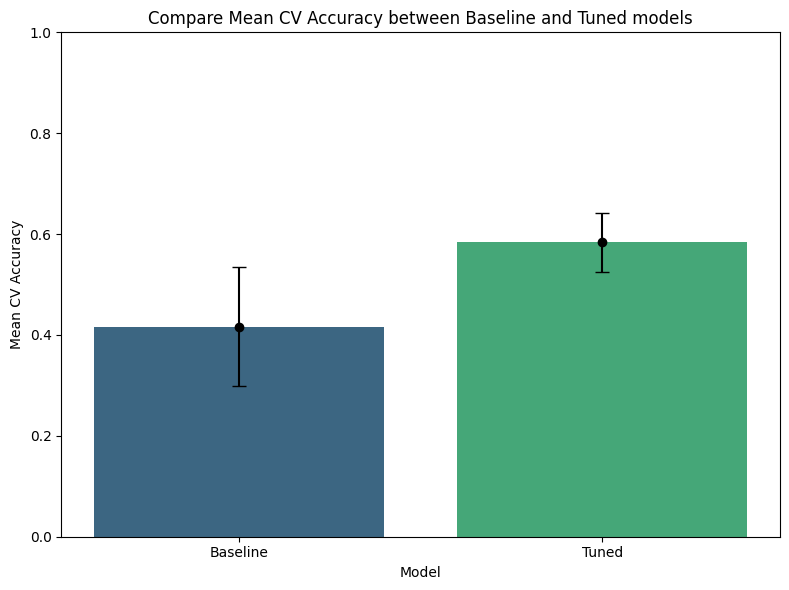

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Mean CV Accuracy', data=comparison_df, palette='viridis', hue='Model', legend=False)
plt.errorbar(x=comparison_df['Model'], y=comparison_df['Mean CV Accuracy'], yerr=comparison_df['Std CV Accuracy'], fmt='o', color='black', capsize=5)
plt.title('Compare Mean CV Accuracy between Baseline and Tuned models')
plt.xlabel('Model')
plt.ylabel('Mean CV Accuracy')
plt.ylim(0, 1) # Limit the y-axis from 0 to 1
plt.tight_layout()
plt.show()

3.B&B decision promote

✅ Data loaded successfully!
Total rows: 30
------------------------------
Train size: 24 | Test size: 6
------------------------------

🔍 Running Grid Search to find optimal hyperparameters...
Best Params: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.5000 (Recommended metric for reporting)
Test Set Accuracy: 0.5000


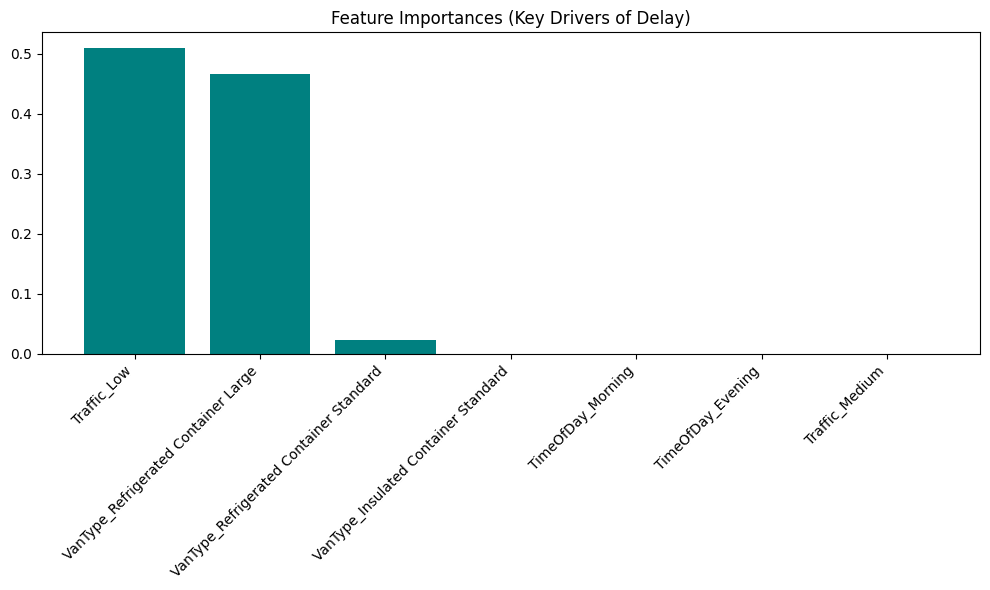


🚀 STARTING BRANCH & BOUND (OPTIMAL FEATURE SUBSET SEARCH)
 -> Found New Best: 0.7500 using ['Traffic_Low']
------------------------------------------------------------
🏆 FINAL BRANCH & BOUND RESULTS:
 - Best Feature Subset: ['Traffic_Low']
 - Best Accuracy (CV):  0.7500
 - Pruned Branches Count: 10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# =============================================================================
# 1. DATA EMBEDDING (HARDCODED DATASET)
# =============================================================================
data = {
    'Traffic': ['Low', 'High', 'High', 'Low', 'High', 'High', 'High', 'High', 'High', 'Low',
                'Medium', 'Medium', 'Low', 'High', 'High', 'Medium', 'Medium', 'High', 'High', 'Medium',
                'High', 'Low', 'Medium', 'Medium', 'Medium', 'High', 'Medium', 'High', 'Low', 'Medium'],
    'TimeOfDay': ['Afternoon', 'Evening', 'Evening', 'Morning', 'Morning', 'Evening', 'Morning', 'Evening', 'Morning', 'Afternoon',
                  'Afternoon', 'Evening', 'Morning', 'Afternoon', 'Morning', 'Evening', 'Evening', 'Evening', 'Morning', 'Evening',
                  'Morning', 'Morning', 'Morning', 'Afternoon', 'Morning', 'Afternoon', 'Morning', 'Afternoon', 'Evening', 'Morning'],
    'VanType': ['Insulated Container Large', 'Insulated Container Standard', 'Refrigerated Container Standard', 'Insulated Container Standard', 'Insulated Container Standard', 'Refrigerated Container Large', 'Refrigerated Container Standard', 'Refrigerated Container Large', 'Refrigerated Container Standard', 'Refrigerated Container Standard',
                'Refrigerated Container Standard', 'Refrigerated Container Standard', 'Insulated Container Large', 'Refrigerated Container Standard', 'Insulated Container Standard', 'Refrigerated Container Large', 'Refrigerated Container Standard', 'Insulated Container Standard', 'Insulated Container Large', 'Refrigerated Container Standard',
                'Insulated Container Standard', 'Refrigerated Container Large', 'Refrigerated Container Large', 'Refrigerated Container Large', 'Refrigerated Container Standard', 'Refrigerated Container Standard', 'Refrigerated Container Standard', 'Insulated Container Standard', 'Refrigerated Container Standard', 'Refrigerated Container Large'],
    'Delayed': ['No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
                'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes',
                'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Convert target variable (Delayed) to binary: Yes=1, No=0
df['Delayed'] = df['Delayed'].map({'Yes': 1, 'No': 0})

print("✅ Data loaded successfully!")
print(f"Total rows: {len(df)}")
print("-" * 30)

# =============================================================================
# 2. DATA PREPROCESSING
# =============================================================================
X_raw = df[['Traffic', 'TimeOfDay', 'VanType']]
y = df['Delayed']

# Manual One-Hot Encoding for better column control
# drop_first=True to avoid multicollinearity
X_encoded = pd.get_dummies(X_raw, drop_first=True)
feature_names = X_encoded.columns.tolist()

# Train/Test Split (80/20) - Using seed 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print("-" * 30)

# =============================================================================
# 3. DECISION TREE + GRID SEARCH (MAIN - PART 3)
# =============================================================================
print("\n🔍 Running Grid Search to find optimal hyperparameters...")

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2]
}

# 3-Fold CV is used due to small dataset size
grid = GridSearchCV(dt, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_acc_cv = grid.best_score_
test_acc = best_model.score(X_test, y_test)

print(f"Best Params: {grid.best_params_}")
print(f"Best CV Accuracy: {best_acc_cv:.4f} (Recommended metric for reporting)")
print(f"Test Set Accuracy: {test_acc:.4f}")

# Visualization: Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Key Drivers of Delay)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# =============================================================================
# 4. BRANCH & BOUND FOR FEATURE SELECTION (ADDITIONAL - PART 4 SUPPORT)
# =============================================================================
print("\n" + "="*60)
print("🚀 STARTING BRANCH & BOUND (OPTIMAL FEATURE SUBSET SEARCH)")
print("="*60)

class FeatureBnB:
    def __init__(self, X, y, feature_list):
        self.X = X
        self.y = y
        self.feature_list = feature_list
        self.best_score = 0.0
        self.best_subset = []
        self.pruned_count = 0

    def evaluate(self, subset):
        if not subset: return 0.0
        # Use Cross Validation to evaluate subset quality
        clf = DecisionTreeClassifier(max_depth=2, random_state=42)
        scores = cross_val_score(clf, self.X[subset], self.y, cv=3)
        return scores.mean()

    def solve(self):
        self._recursive([], 0)
        return self.best_subset, self.best_score

    def _recursive(self, current_subset, start_idx):
        # 1. Evaluate current branch (subset)
        current_score = self.evaluate(current_subset)

        # Update if better score found
        if current_score > self.best_score:
            self.best_score = current_score
            self.best_subset = current_subset[:]
            print(f" -> Found New Best: {current_score:.4f} using {current_subset}")

        # 2. Pruning - Heuristic
        # If current subset performs poorly (<50%), prune this branch
        if len(current_subset) > 0 and current_score < 0.5:
            self.pruned_count += 1
            return

        # 3. Branching (Add next feature)
        for i in range(start_idx, len(self.feature_list)):
            new_subset = current_subset + [self.feature_list[i]]
            self._recursive(new_subset, i + 1)

# Run B&B on Training set to prevent data leakage
bnb = FeatureBnB(X_train, y_train, feature_names)
best_subset, best_score = bnb.solve()

print("-" * 60)
print(f"🏆 FINAL BRANCH & BOUND RESULTS:")
print(f" - Best Feature Subset: {best_subset}")
print(f" - Best Accuracy (CV):  {best_score:.4f}")
print(f" - Pruned Branches Count: {bnb.pruned_count}")
print("="*60)